In [1]:
import os
import torch

if 'PATH_SET' not in locals():
    os.chdir('..')
    PATH_SET = True
    os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'

    os.environ['OMP_NUM_THREADS'] = '1'
    os.environ['MKL_NUM_THREADS'] = '1'

    torch.set_num_threads(1)
    torch.set_num_interop_threads(1)
    
import matplotlib.pyplot as plt
import matplotlib.style as style
style.use('https://raw.githubusercontent.com/dominik-strutz/dotfiles/main/mystyle.mplstyle')


from helpers.likelihood import (
    logistic_picking_likelihood_tt,
    DataLikelihoodAttenuation,
    DataLikelihood,
    # DataLikelihoodPLArrival,
    # DataLikelihoodArrival,
)

from helpers.forward import Homogeneous_Forward_Function

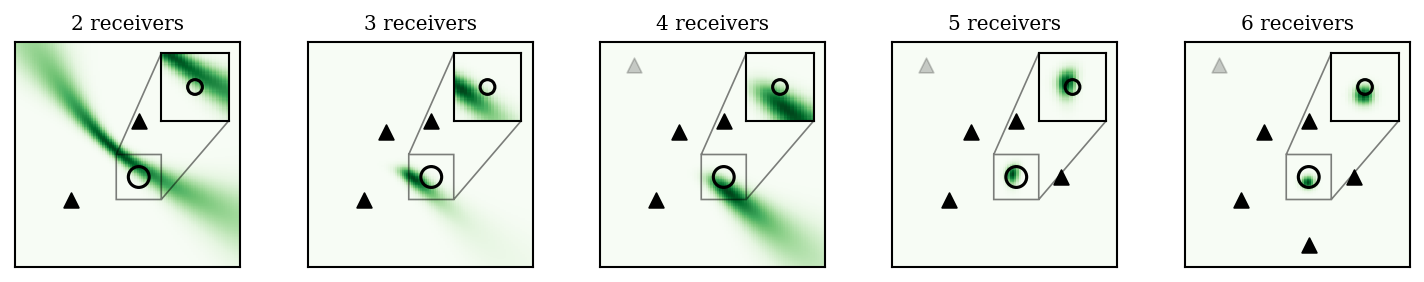

In [2]:
x_min, x_max = 0, 2_000
y_min, y_max = 0, 2_000


x_posterior = torch.linspace(x_min, x_max, 100)
y_posterior = torch.linspace(y_min, y_max, 300)


# Set random seed for reproducibility
torch.manual_seed(0)

# Define specific number of receivers to consider
receiver_counts = [2, 3, 4, 5, 6]
# receiver_counts = [1, 2, 3,]

n_plots = len(receiver_counts)

# Create a figure with an adjustable number of subplots based on arrival data requirements
fig, axes = plt.subplots(1, n_plots, figsize=(n_plots*2+2, 4), sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.3, wspace=0.3)
fig.set_facecolor('white')

all_receivers = torch.tensor([
    [500.0, 600.0],
    [1100.0, 1300.0],
    [700.0, 1200.0],
    [300.0, 1800.0],
    [1500.0, 800.0],
    [1100.0, 200.0],
])

true_event = torch.tensor([1100., 800.])
true_velocity = 2500.

forward_function = Homogeneous_Forward_Function(true_velocity)

# Create data likelihood objects for traveltime and arrival data
# Set parameters for the likelihood models
vel_sigma = 0.05  # Velocity uncertainty
tt_obs_std = 0.01  # Observation standard deviation
dependence_distance = 0  # Spatial correlation distance
# dependence_distance = 100.0  # Spatial correlation distance

picking_likelihood = logistic_picking_likelihood_tt(b = -30, c = 0.5,)

data_likelihood_att = DataLikelihoodAttenuation(
    forward_function=forward_function,
    vel_sigma=vel_sigma,
    picking_likelihood=picking_likelihood,
    tt_obs_std=tt_obs_std,
    dependence_distance=dependence_distance,
)

data_likelihood = DataLikelihood(
    forward_function=forward_function,
    vel_sigma=vel_sigma,
    tt_obs_std=tt_obs_std,
    dependence_distance=dependence_distance,
)


# Define zoom parameters for inset
zoom_radius = 200  # Size of zoom area around true event
zoom_x_min, zoom_x_max = true_event[0] - zoom_radius, true_event[0] + zoom_radius
zoom_y_min, zoom_y_max = true_event[1] - zoom_radius, true_event[1] + zoom_radius

# Loop through each number of receivers
for i, n_rec in enumerate(receiver_counts):
    # Get the current set of receivers
    current_receivers = all_receivers[:n_rec, :]
   
    # Calculate log likelihood for grid of points
    X_posterior, Y_posterior = torch.meshgrid(
        x_posterior, y_posterior, indexing='ij')
    
    posterior_grid_full = torch.stack(
        [X_posterior.ravel(), Y_posterior.ravel()], dim=-1)
    

    dl = data_likelihood_att(
        torch.tensor([0.5]).unsqueeze(0),
        true_event.unsqueeze(0), current_receivers)

    tt_obs = dl.sample().squeeze(0)
    
    # Create a mask to filter out observations with high standard deviation
    # Get the diagonal of the covariance matrix (which has standard deviations)
    try:
        tt_obs_cov = dl.scale_tril
        std_diag = torch.sqrt(torch.diagonal(tt_obs_cov.squeeze(0)))
        multivariate_normal = True
    except AttributeError:
        tt_obs_cov = dl.base_dist.scale.squeeze(0)
        std_diag = tt_obs_cov
        multivariate_normal = False
        
    # Create a mask for observations with standard deviation less than 0.5
    mask = std_diag < 0.5 # hard coded std if SNR is too low
    # Print the mask shape to verify

    design_tmp = current_receivers[mask]
    design_tmp = design_tmp.squeeze(0) if design_tmp.ndim > 2 else design_tmp
    if multivariate_normal:
        tt_obs_cov = tt_obs_cov[..., mask, :][..., mask]
    else:
        tt_obs_cov = tt_obs_cov[mask]
    
    tt_obs = tt_obs[mask]
        
    # Calculate log likelihood for traveltime data
    log_p_tt = data_likelihood(
        posterior_grid_full,
        design_tmp,
        ).log_prob(tt_obs).reshape(
            x_posterior.shape[0], y_posterior.shape[0])
    
    # Plot traveltime data likelihood
    ax_tt = axes[i]
    cs_tt = ax_tt.pcolormesh(X_posterior, Y_posterior, log_p_tt.exp(), cmap='Greens', shading='auto')
    ax_tt.scatter(
        current_receivers[..., 0], current_receivers[..., 1], c='k', marker='^', s=50, alpha=0.2,)
    ax_tt.scatter(
        design_tmp[..., 0], design_tmp[..., 1], c='k', marker='^', s=50, label='Receivers')
    ax_tt.scatter(
        true_event[0], true_event[1], facecolor='none',
        marker='o', s=100, edgecolors='black', linewidths=1.5, label='True event')

    # Add zoomed-in inset for traveltime plot - moved to top right corner
    axins_tt = ax_tt.inset_axes([0.65, 0.65, 0.3, 0.3])
    axins_tt.pcolormesh(X_posterior, Y_posterior, log_p_tt.exp(), cmap='Greens', shading='auto')
    axins_tt.scatter(
        true_event[0], true_event[1], facecolor='none', 
        marker='o', s=50, edgecolors='black', linewidths=1.5)
    axins_tt.set_xlim(zoom_x_min, zoom_x_max)
    axins_tt.set_ylim(zoom_y_min, zoom_y_max)
    axins_tt.set_xticks([])
    axins_tt.set_yticks([])
    ax_tt.indicate_inset_zoom(axins_tt, edgecolor="black")
    
    ax_tt.set_title(f'{n_rec} receiver{"s" if n_rec > 1 else ""}')
    ax_tt.set_aspect('equal')
    ax_tt.set_xlim(x_min, x_max)
    ax_tt.set_ylim(y_min, y_max)
    ax_tt.set_xticks([])
    ax_tt.set_yticks([])

# # Add a common legend for the whole figure
# handles, labels = ax_tt.get_legend_handles_labels()
# axes[0].legend(handles, labels, loc='center', ncol=1, fontsize=10)

plt.show()

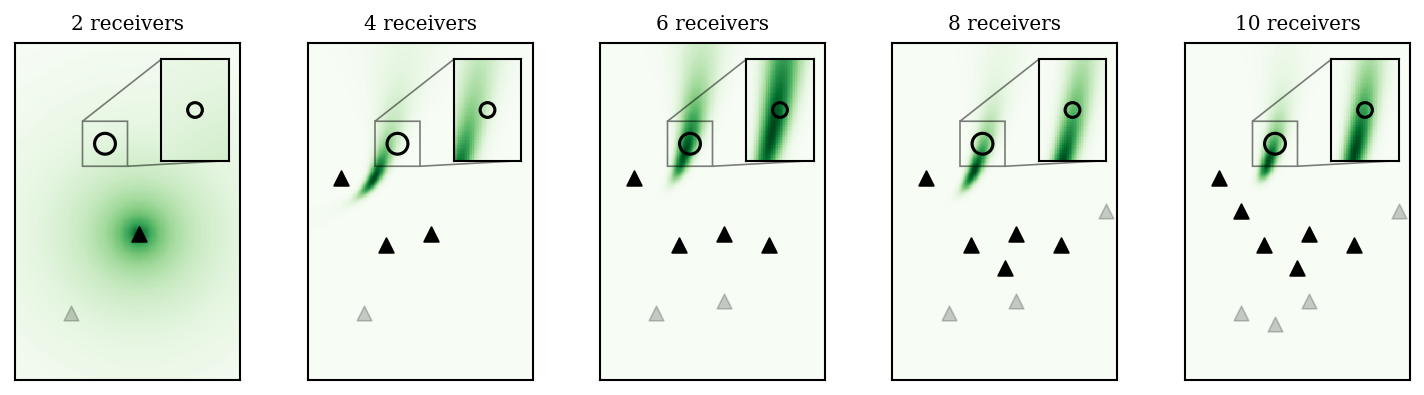

In [3]:
x_min, x_max = 0, 2_000
y_min, y_max = 0, 3_000

x_posterior = torch.linspace(x_min, x_max, 200)
y_posterior = torch.linspace(y_min, y_max, 300)


# Set random seed for reproducibility
torch.manual_seed(0)

# Define specific number of receivers to consider
receiver_counts = [2, 4, 6, 8, 10]
n_plots = len(receiver_counts)

# Create a figure with subplots for traveltime data only
fig, axes = plt.subplots(1, n_plots, figsize=(n_plots*2+2, 4), sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.3, wspace=0.3)
fig.set_facecolor('white')

all_receivers = torch.tensor([
    [500.0, 600.0],
    [1100.0, 1300.0],
    [700.0, 1200.0],
    [300.0, 1800.0],
    [1500.0, 1200.0],
    [1100.0, 700.0],
    [1900.0, 1500.0],
    [1000.0, 1000.0],
    [800.0, 500.0],
    [500.0, 1500.0],
])

true_event = torch.tensor([800., 2100.])

# Define zoom parameters for inset
zoom_radius = 200  # Size of zoom area around true event
zoom_x_min, zoom_x_max = true_event[0] - zoom_radius, true_event[0] + zoom_radius
zoom_y_min, zoom_y_max = true_event[1] - zoom_radius, true_event[1] + zoom_radius

# Loop through each number of receivers
for i, n_rec in enumerate(receiver_counts):
        # Get the current set of receivers
    current_receivers = all_receivers[:n_rec, :]
   
    # Calculate log likelihood for grid of points
    X_posterior, Y_posterior = torch.meshgrid(
        x_posterior, y_posterior, indexing='ij')
    
    posterior_grid_full = torch.stack(
        [X_posterior.ravel(), Y_posterior.ravel()], dim=-1)
    

    dl = data_likelihood_att(
        torch.tensor([0.5]).unsqueeze(0),  # Dummy nuisance parameter
        true_event.unsqueeze(0), current_receivers)
    
    tt_obs = dl.sample().squeeze(0)
    
    # Create a mask to filter out observations with high standard deviation
    # Get the diagonal of the covariance matrix (which has standard deviations)
    try:
        tt_obs_cov = dl.scale_tril
        std_diag = torch.sqrt(torch.diagonal(tt_obs_cov.squeeze(0)))
        multivariate_normal = True
    except AttributeError:
        tt_obs_cov = dl.base_dist.scale.squeeze(0)
        std_diag = tt_obs_cov
        multivariate_normal = False
        
    # Create a mask for observations with standard deviation less than 0.5
    mask = std_diag < 0.5 # hard coded std if SNR is too low
    # Print the mask shape to verify

    design_tmp = current_receivers[mask]
    design_tmp = design_tmp.squeeze(0) if design_tmp.ndim > 2 else design_tmp
    if multivariate_normal:
        tt_obs_cov = tt_obs_cov[..., mask, :][..., mask]
    else:
        tt_obs_cov = tt_obs_cov[mask]
    
    tt_obs = tt_obs[mask]
    # Calculate log likelihood for traveltime data
    log_p_tt = data_likelihood(
        posterior_grid_full, design_tmp,
        ).log_prob(tt_obs).reshape(
            x_posterior.shape[0], y_posterior.shape[0])
    
    # Plot traveltime data likelihood
    ax_tt = axes[i]
    cs_tt = ax_tt.pcolormesh(X_posterior, Y_posterior, log_p_tt.exp(), cmap='Greens', shading='auto')
    ax_tt.scatter(
        current_receivers[..., 0], current_receivers[..., 1], c='k', marker='^', s=50, alpha=0.2,)
    ax_tt.scatter(
        design_tmp[..., 0], design_tmp[..., 1], c='k', marker='^', s=50, label='Receivers')
    ax_tt.scatter(
        true_event[0], true_event[1], facecolor='none',
        marker='o', s=100, edgecolors='black', linewidths=1.5, label='True event')

    # Add zoomed-in inset for traveltime plot - moved to top right corner
    axins_tt = ax_tt.inset_axes([0.65, 0.65, 0.3, 0.3])
    axins_tt.pcolormesh(X_posterior, Y_posterior, log_p_tt.exp(), cmap='Greens', shading='auto')
    axins_tt.scatter(true_event[0], true_event[1], facecolor='none', 
                    marker='o', s=50, edgecolors='black', linewidths=1.5)
    axins_tt.set_xlim(zoom_x_min, zoom_x_max)
    axins_tt.set_ylim(zoom_y_min, zoom_y_max)
    axins_tt.set_xticks([])
    axins_tt.set_yticks([])
    ax_tt.indicate_inset_zoom(axins_tt, edgecolor="black")
    
    ax_tt.set_title(f'{n_rec} receiver{"s" if n_rec > 1 else ""}')
    ax_tt.set_aspect('equal')
    ax_tt.set_xlim(x_min, x_max)
    ax_tt.set_ylim(y_min, y_max)
    ax_tt.set_xticks([])
    ax_tt.set_yticks([])

# # Add a common legend for the whole figure
# handles, labels = ax_tt.get_legend_handles_labels()
# axes[0].legend(handles, labels, loc='center', ncol=1, fontsize=10)
plt.show()